# Numerical Simulation Laboratory - Exercise 05.1

## INTRODUCTION

The purpose of this exercise is to use the Metropolis algorithm to sample the electron probability density of the Hydrogen atom and to estimate the expectation value of the radius. Distances are expressed in Bohr radius units, so in the numerical code $a_0$ is set equal to 1.

The key point is that in quantum mechanics the wave function itself is a probability amplitude, while the probability density for the position of the particle is the squared modulus $|\Psi(\mathbf r)|^2$. Therefore, by generating points distributed according to $|\Psi(\mathbf r)|^2$, the expectation value of any observable depending on the position can be estimated as a Monte Carlo average. In this exercise the observable is

$$
r = \sqrt{x^2+y^2+z^2}.
$$

### Hydrogen atom


The wave functions of the eigenstates of an electron in a Hydrogen atom are known analytically. In fact, the Hydrogen atom is the only atom for which the Schrödinger equation can be solved exactly. These wave functions are naturally expressed in spherical coordinates, in terms of spherical harmonics and generalized Laguerre polynomials.

The wave function can be separated into a radial part and an angular part:

$$
\Psi_{n,l,m}(r,\theta,\phi)=
\sqrt{\left(\frac{2}{na_0}\right)^3 \frac{(n-l-1)!}{2n[(n+l)!]}}
e^{-r/(na_0)}\left(\frac{2r}{na_0}\right)^l 
L_{n-l-1}^{2l+1}\left(\frac{2r}{na_0}\right)
Y_l^m(\theta,\phi)
$$

where $a_0=4\pi\epsilon_0\hbar^2/(m_e e^2)=0.0529$ nm is the Bohr radius, $L_{n-l-1}^{2l+1}$ are the generalized Laguerre polynomials, $Y_l^m(\theta,\phi)$ are the spherical harmonics, $n=1,2,\ldots$ is the principal quantum number, $l=0,1,\ldots,n-1$ is the azimuthal quantum number, and $m=-l,\ldots,l$ is the magnetic quantum number.

This exercise focuses on two specific states. The ground state (100) wave function is

$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0},
$$

whereas one of the three $2p$ excited states (210) is

$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}}\, r\, e^{-r/(2a_0)} \cos\theta .
$$

The corresponding exact expectation values of the radius are

$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0,
\qquad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5a_0 .
$$

In the simulation, distances are expressed in units of $a_0$, so these theoretical reference values become

$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = 1.5,
\qquad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5.
$$

The quantities actually sampled by the Metropolis algorithm are the squared moduli of these wave functions, because $|\Psi(\mathbf r)|^2$ is the probability density for the electron position.


### The Metropolis algorithm

The Metropolis algorithm is a Markov Chain Monte Carlo method. Its goal is to sample a target probability density $p(\mathbf{x})$ when direct sampling is difficult or practically impossible. This makes it especially useful for analytically complicated and high-dimensional distributions, and also when the normalization constant of $p(\mathbf{x})$ is unknown. In this exercise the target density is

$$
p(\mathbf{r}) = |\Psi(\mathbf{r})|^2.
$$

The algorithm constructs a Markov chain, i.e. a sequence of configurations $\mathbf{x}_0,\mathbf{x}_1,\ldots$, in which the next configuration depends only on the present one. If the transition rule is chosen correctly, the asymptotic distribution of the chain is the desired density $p(\mathbf{x})$.

At a generic step, starting from the current point $\mathbf{y}$, a trial point $\mathbf{x}$ is proposed according to a transition probability $T(\mathbf{x}|\mathbf{y})$. The move is then accepted with probability

$$
A(\mathbf{x}|\mathbf{y})=\min\left[1,\frac{T(\mathbf{y}|\mathbf{x})p(\mathbf{x})}{T(\mathbf{x}|\mathbf{y})p(\mathbf{y})}\right].
$$

Here $p(\mathbf{y})$ is the target probability density evaluated at the current point, while $p(\mathbf{x})$ is the target probability density evaluated at the proposed point. If the move is accepted, the chain moves to $\mathbf{x}$; otherwise it remains at $\mathbf{y}$.

The transition kernel $K(\mathbf{x}|\mathbf{y})$ is the probability rule that defines the evolution of the Markov chain: it gives the probability density of moving from the current point $\mathbf{y}$ to the next point $\mathbf{x}$. In the Metropolis algorithm, the transition probability is built from this proposal step and from the acceptance probability,

$$
K(\mathbf{x}|\mathbf{y}) = T(\mathbf{x}|\mathbf{y})A(\mathbf{x}|\mathbf{y}).
$$

Here $T(\mathbf{x}|\mathbf{y})$ is the proposal probability, which generates a trial move, while $A(\mathbf{x}|\mathbf{y})$ is the acceptance probability, which decides whether the proposed move is accepted. The Metropolis acceptance rule is constructed so that the transition kernel satisfies **detailed balance**,

$$
K(\mathbf{x}|\mathbf{y})p(\mathbf{y})=K(\mathbf{y}|\mathbf{x})p(\mathbf{x}).
$$

This condition ensures that the Markov process admits a stationary distribution. With the Metropolis acceptance rule, this stationary distribution is constructed to coincide with the desired target probability density $p$. For the sampling to be effective, the Markov chain must also be able to explore the relevant regions of the configuration space, without remaining confined to only one part of it. This is the practical meaning of ergodicity in the present context. Therefore, after an initial equilibration time, the generated configurations can be used as samples of $p$.

A crucial practical point is that this convergence is not immediate: the first configurations can still be strongly influenced by the initial condition. Therefore, before measuring observables, the chain must be equilibrated. An initial part of the trajectory is discarded so that the sampled configurations are representative of the target distribution and not of the arbitrary starting point.

In the present simulation both the uniform and the Gaussian transition probabilities are symmetric,

$$
T(\mathbf{x}|\mathbf{y})=T(\mathbf{y}|\mathbf{x}).
$$

The acceptance probability therefore reduces to the usual Metropolis rule

$$
A(\mathbf{x}|\mathbf{y})=\min\left[1,\frac{p(\mathbf{x})}{p(\mathbf{y})}\right].
$$

This is very useful because the **normalization** of $p$ is **not needed**: any constant factor cancels in the ratio. This is one of the main strengths of the method. The price to pay is that the generated points are not independent: consecutive configurations are correlated. For this reason the chain must be equilibrated before starting the measurement, and data blocking is used to estimate the statistical uncertainty.

The importance of equilibration becomes especially visible when the chain starts very far from the typical region of the target distribution. In that case, the first configurations describe the approach to equilibrium rather than the equilibrium distribution itself. Keeping those configurations in the measurement would bias the estimate of $\langle r\rangle$.

The choice of the proposal step is also important. If the step is too large, most proposed moves fall in low-probability regions and are rejected. If the step is too small, most moves are accepted but the chain explores the space very slowly and produces strongly correlated samples. Following the empirical rule discussed in the lecture, the proposal parameters were tuned to obtain an acceptance rate close to $50\%$.

## EXERCISE 05.1

### Assignment prompt

### Exercise 05.1


Use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ **in Cartesian coordinates** using, initially, an uniform transition probability $T(\vec{x}|\vec{y})$. Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.

Show a picture of your estimations of $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^6$) as a function of the number of blocks, $N$</font>.

- Use Bohr radius units, $a_0$ for distances
- Choose the step of the uniform transition probability $T(\vec{x}|\vec{y})$ in order to obtain 50% of acceptance in both cases
- Choose a reasonable starting point in the 3D space and equilibrate your sampling before to start measuring the radius. What do you observe when you start very far from the origin?
- How large should be the number of Monte Carlo Metropolis steps in each block?
- If you use a multivariate normal transition probability $T(\vec{x}|\vec{y})$, i.e. a Gaussian for each coordinate, your results for $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$ are equivalent?


### Method

The simulation is performed in Cartesian coordinates and in units of $a_0$. Starting from the Hydrogen wave functions introduced above, and setting $a_0=1$, the two target probability densities are obtained from their squared moduli. Since

$$
r=\sqrt{x^2+y^2+z^2}, \qquad r\cos\theta=z,
$$

the densities sampled by the Metropolis algorithm are

$$
|\Psi_{1,0,0}(x,y,z)|^2 = \frac{1}{\pi}e^{-2r},
$$

and

$$
|\Psi_{2,1,0}(x,y,z)|^2 = \frac{1}{32\pi}z^2e^{-r}.
$$

The normalization constants are included in the C++ functions, but they are not essential for the Metropolis sampling, because they cancel in the acceptance ratio.

For each state, both a uniform proposal and a Gaussian proposal were used. The proposal parameters, namely the uniform step size $\delta$ and the Gaussian standard deviation $\sigma$, were tuned to obtain an acceptance rate close to $50\%$. The resulting acceptance rates were printed by the C++ code:

| State | Proposal | Parameter | Acceptance rate |
|---|---:|---:|---:|
| $1s$ | uniform | $\delta=1.2$ | $0.508$ |
| $2p$ | uniform | $\delta=2.95$ | $0.504$ |
| $1s$ | Gaussian | $\sigma=0.75$ | $0.505$ |
| $2p$ | Gaussian | $\sigma=1.85$ | $0.505$ |

The averages are computed with **$M=10^7$** Metropolis **steps** divided into **$N=100$ blocks**, therefore each block contains $10^5$ steps. For the standard runs, reasonable starting points are used: $(0.1,0.1,0.1)$ for the $1s$ state and $(0,0,2)$ for the $2p$ state. In these runs an initial equilibration (1000 steps) is performed before accumulating the averages, so that the measurements are not affected by the arbitrary initial condition.


### C++ implementation

#### Target densities

The C++ code implements the target densities directly in Cartesian coordinates. The normalization constants are included in the functions to keep the connection with the analytical wave functions explicit, even if they are not essential in the Metropolis ratio because they cancel between the proposed and the current configuration.

```c++
double fundamental_wave_function_squared_modulus(double x, double y, double z){
    double modulus_2 = (1/M_PI) * exp(-2*sqrt(x*x + y*y + z*z));
    return modulus_2;
}

double excited_wave_function_squared_modulus(double x, double y, double z){
    double r = sqrt(x*x + y*y + z*z);
    return (1.0/(32.0*M_PI)) * z*z * exp(-r);
}
```

#### Acceptance step

For the uniform and Gaussian proposals used in this simulation, the transition probability is symmetric,

$$
T(\mathbf{x}|\mathbf{y}) = T(\mathbf{y}|\mathbf{x}).
$$

Therefore the proposal terms cancel in the acceptance ratio, and the Metropolis acceptance probability is computed only from the ratio between the target density at the proposed point and at the current point. The following C++ function shows the acceptance step for the $1s$ state:

```c++
bool A_fundamental(Random &rnd, double x, double y, double z, double x_new, double y_new, double z_new, int &accepted_per_block){

    double A = min(1.0,fundamental_wave_function_squared_modulus(x_new,y_new,z_new) / fundamental_wave_function_squared_modulus(x,y,z));

    if(rnd.Rannyu() < A){
        accepted_per_block++;
        return true;
    }
    return false;
}
```

The same structure is used for the $2p$ state, replacing the target density with `excited_wave_function_squared_modulus`.

#### Metropolis move

The acceptance function is used inside the complete Metropolis move. First, a trial configuration is proposed. Then, if the move is accepted, the current coordinates are updated; otherwise they remain unchanged. In both cases, the function returns the radius of the current configuration, which is the quantity accumulated in the block average.

```c++
double metropolis_uniform_fundamental(Random &rnd, double &x, double &y, double &z, int &accepted_per_block){

    double x_new = x + rnd.Rannyu(-1.2, 1.2);
    double y_new = y + rnd.Rannyu(-1.2, 1.2);
    double z_new = z + rnd.Rannyu(-1.2, 1.2);

    if(A_fundamental(rnd, x, y, z, x_new, y_new, z_new, accepted_per_block)){
        x = x_new;
        y = y_new;
        z = z_new;
    }

    return sqrt(x*x + y*y + z*z);
}
```

The same structure is used for the other cases, changing the proposal step and the target density.

#### Proposal steps and tuning

The trial move is generated by changing the three Cartesian coordinates. The proposal parameters, namely the uniform step size $\delta$ and the Gaussian standard deviation $\sigma$, were tuned to obtain an acceptance rate close to $50\%$.

```c++
// Uniform proposal, 1s state                   // Uniform proposal, 2p state 
x_new = x + rnd.Rannyu(-1.2, 1.2);              x_new = x + rnd.Rannyu(-2.95, 2.95);
y_new = y + rnd.Rannyu(-1.2, 1.2);              y_new = y + rnd.Rannyu(-2.95, 2.95);
z_new = z + rnd.Rannyu(-1.2, 1.2);              z_new = z + rnd.Rannyu(-2.95, 2.95);


// Gaussian proposal, 1s state                  // Gaussian proposal, 2p state 
x_new = x + rnd.Gauss(0, 0.75);                 x_new = x + rnd.Gauss(0, 1.85);
y_new = y + rnd.Gauss(0, 0.75);                 y_new = y + rnd.Gauss(0, 1.85);
z_new = z + rnd.Gauss(0, 0.75);                 z_new = z + rnd.Gauss(0, 1.85);
```

#### Equilibration

Before starting the measurements, the standard simulation discards an initial equilibration part of 1000 steps. This is done after choosing a reasonable initial point and before accumulating block averages. For example, for the uniform proposal the code equilibrates the $1s$ and $2p$ chains as follows:

```c++
// 1s state: reasonable starting point
double x = 0.1;
double y = 0.1;
double z = 0.1;

// initial equilibration
for(int i=0; i<1000; i++){
    int dummy = 0;
    metropolis_uniform_fundamental(rnd, x, y, z, dummy);
}
```

```c++
// 2p state: reasonable starting point
double x = 0.0;
double y = 0.0;
double z = 2.0;

// initial equilibration
for(int i=0; i<1000; i++){
    int dummy = 0;
    metropolis_uniform_excited(rnd, x, y, z, dummy);
}
```

The same equilibration structure is used for the Gaussian proposal, replacing the Metropolis move with `metropolis_gaussian_fundamental` or `metropolis_gaussian_excited`.


Only after this burn-in part is completed, the radius is accumulated block by block, and the progressive averages and uncertainties are computed with the usual blocking method.


### Ground state (100)

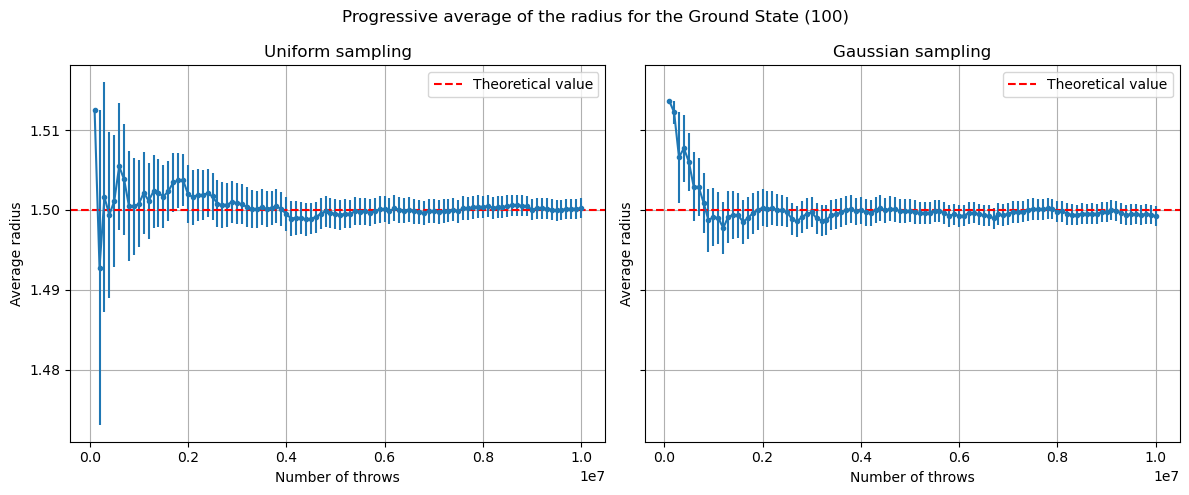

In [40]:
# Initial conditions: (x,y,z) = (0.1,0.1,0.1)
# 10^7 throws, 100 blocks -> 10^5 throws per block

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("Results/Esercizio_05.1_results.txt", sep = ";")


# total number of throws and blocks 
N_throws = 10000000
N_blocks = 100
throws_per_block = N_throws/N_blocks   # number of throws in each block

x = np.arange(1, N_blocks+1) * throws_per_block   # progressive number of throws

fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

fig.suptitle("Progressive average of the radius for the Ground State (100)")

axs[0].errorbar(x, data["Progressive_r_uniform_fundamental"], yerr=data["Progressive_r_uniform_fundamental_error"], fmt="-o", ms=3)
axs[0].set_title("Uniform sampling")
axs[0].set_xlabel("Number of throws")
axs[0].set_ylabel("Average radius")
axs[0].axhline(1.5, color='r', linestyle='--', label="Theoretical value")
axs[0].grid(True)
axs[0].legend()

axs[1].errorbar(x, data["Progressive_r_gaussian_fundamental"], yerr=data["Progressive_r_gaussian_fundamental_error"], fmt="-o", ms=3)
axs[1].set_title("Gaussian sampling")
axs[1].set_xlabel("Number of throws")
axs[1].set_ylabel("Average radius")
axs[1].axhline(1.5, color='r', linestyle='--', label="Theoretical value")
axs[1].grid(True)
axs[1].legend() 


plt.tight_layout()
plt.show()

#### Comment 

For the ground state, both transition probabilities give a progressive estimate compatible with the theoretical value

$$
\langle r \rangle_{1s}=\frac{3}{2}a_0.
$$

The uniform and Gaussian proposals lead to equivalent results within the statistical uncertainty. This confirms that the estimated expectation value does not depend on the specific symmetric proposal distribution, provided that the Metropolis sampling is correctly equilibrated and the acceptance rate is properly tuned.

### Excited state (210)

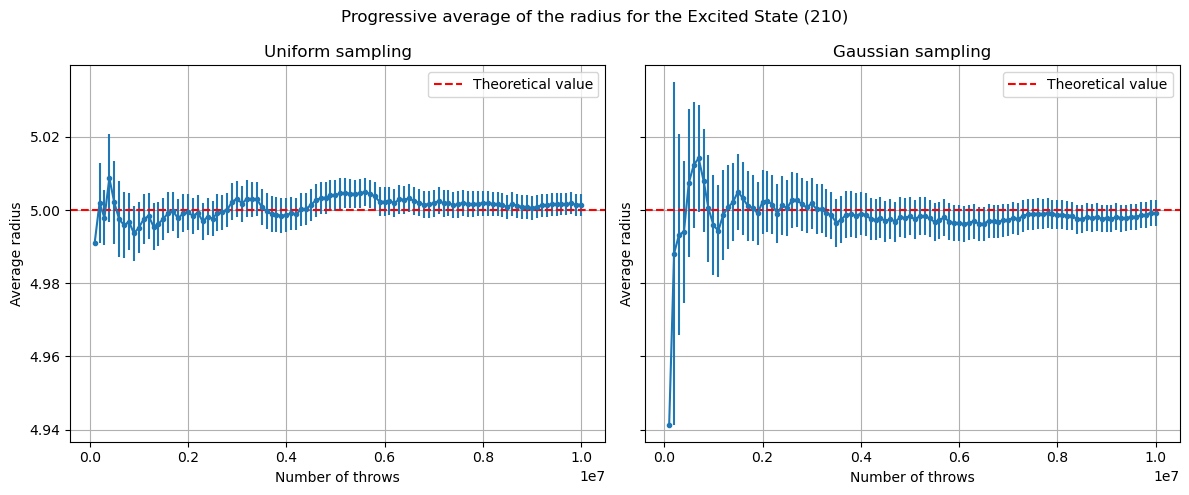

In [41]:
# Initial conditions: (x,y,z) = (0,0,2)
# Initial conditions: (x,y,z) = (0.1,0.1,0.1)
# 10^7 throws, 100 blocks -> 10^5 throws per block

fig, axs = plt.subplots(1, 2, figsize=(12,5), sharey=True)

fig.suptitle("Progressive average of the radius for the Excited State (210)")

axs[0].errorbar(x, data["Progressive_r_uniform_excited"], yerr=data["Progressive_r_uniform_excited_error"], fmt="-o", ms=3)
axs[0].set_title("Uniform sampling")
axs[0].set_xlabel("Number of throws")
axs[0].set_ylabel("Average radius")
axs[0].axhline(5.0, color='r', linestyle='--', label="Theoretical value")
axs[0].grid(True)
axs[0].legend()

axs[1].errorbar(x, data["Progressive_r_gaussian_excited"], yerr=data["Progressive_r_gaussian_excited_error"], fmt="-o", ms=3)
axs[1].set_title("Gaussian sampling")
axs[1].set_xlabel("Number of throws")
axs[1].set_ylabel("Average radius")
axs[1].axhline(5.0, color='r', linestyle='--', label="Theoretical value")
axs[1].grid(True)
axs[1].legend() 


plt.tight_layout()
plt.show()

#### Comment

For the $2p$ state, the expected value is

$$
\langle r \rangle_{2p}=5a_0.
$$

Also in this case, both transition probabilities give a progressive estimate compatible with the theoretical value. The uniform and Gaussian proposals lead to equivalent results within the statistical uncertainty, showing again that the final estimate is independent of the specific symmetric proposal used in the Metropolis sampling.

### Metropolis sampling of the system configurations

The following plots show the sampled configurations after the initial equilibration. The $1s$ distribution is spherically symmetric and concentrated close to the origin, while the $2p$ distribution has a nodal plane at $z=0$ because the probability density is proportional to $z^2$.

The trajectory files used for these plots are produced during the Metropolis sampling by saving one configuration every 1000 steps:

```c++
for(int j=0; j<throws_per_block; j++){
    sum += metropolis_uniform_fundamental(rnd, x, y, z, accepted_per_block);

    if(j % 1000 == 0){
        trajectory << x << " " << y << " " << z << "\n";
    }
}
```

Therefore, the plotted points are not all the Metropolis configurations, but a subsample of the generated trajectory. This is sufficient to visualize the spatial distribution sampled by the chain.

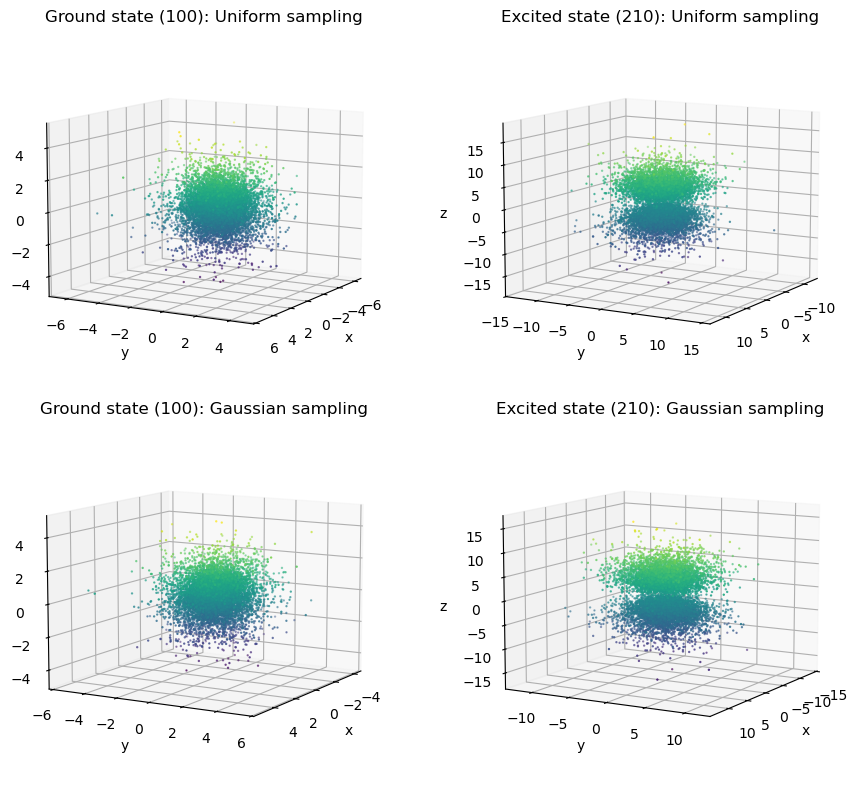

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

df1 = pd.read_csv("trajectories/trajectory_uniform_100.dat", sep=r"\s+")
df2 = pd.read_csv("trajectories/trajectory_uniform_210.dat", sep=r"\s+")
df3 = pd.read_csv("trajectories/trajectory_gaussian_100.dat", sep=r"\s+")
df4 = pd.read_csv("trajectories/trajectory_gaussian_210.dat", sep=r"\s+")

fig = plt.figure(figsize=(10, 8))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

ax1.scatter(df1["x"], df1["y"], df1["z"], c=df1["z"], marker='.', s=2)
ax1.set_title(r"Ground state (100): Uniform sampling")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.view_init(10, 30)

ax2.scatter(df2["x"], df2["y"], df2["z"], c=df2["z"], marker='.', s=2)
ax2.set_title(r"Excited state (210): Uniform sampling")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.view_init(10, 30)

ax3.scatter(df3["x"], df3["y"], df3["z"], c=df3["z"], marker='.', s=2)
ax3.set_title(r"Ground state (100): Gaussian sampling")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.view_init(10, 30)

ax4.scatter(df4["x"], df4["y"], df4["z"], c=df4["z"], marker='.', s=2)
ax4.set_title(r"Excited state (210): Gaussian sampling")
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_zlabel("z")
ax4.view_init(10, 30)

plt.tight_layout()
plt.show()

#### Comment

The sampled configurations reproduce the qualitative shape of the two target probability densities. For the ground state, the points form an approximately spherical cloud centered around the origin, as expected from the spherical symmetry of the $1s$ wave function. For the $2p$ state, the distribution is more extended and shows the characteristic angular dependence of the orbital: the density is lower near the nodal plane $z=0$ and develops mainly along the positive and negative $z$ directions.

The comparison between uniform and Gaussian sampling shows that the spatial distributions are equivalent within the visual statistical fluctuations. This is consistent with the previous estimates of $\langle r\rangle$: after equilibration, the sampled distribution is determined by the target density, while the proposal affects mainly the efficiency of the exploration.

## What do you observe when you start very far from the origin?

To study the role of the initial condition, the simulation was repeated starting from

$$
(x,y,z)=(200,200,200),
$$

which is a region where the target probability density is extremely small. In this test the initial equilibration is intentionally not performed, so that the transient behaviour remains visible in the progressive averages and in the sampled configurations. This is not the correct procedure for a production estimate, but it is useful to show why the equilibration step is important.

In the dedicated far-from-origin program, the only relevant change is that the initial coordinates are set to $(200,200,200)$ and the equilibration loop used in the standard runs is commented out. For example, for the $1s$ state with uniform proposal:

```c++
double x = 200;
double y = 200;
double z = 200;

// // initial equilibration
// for(int i=0; i<1000; i++){
//     int dummy = 0;
//     metropolis_uniform_fundamental(rnd, x, y, z, dummy);
// }
```

The same choice is made for the $2p$ state and for the Gaussian proposal. Therefore, the early part of the Markov chain is kept in the data and the transient approach to the typical region of the target distribution remains visible.

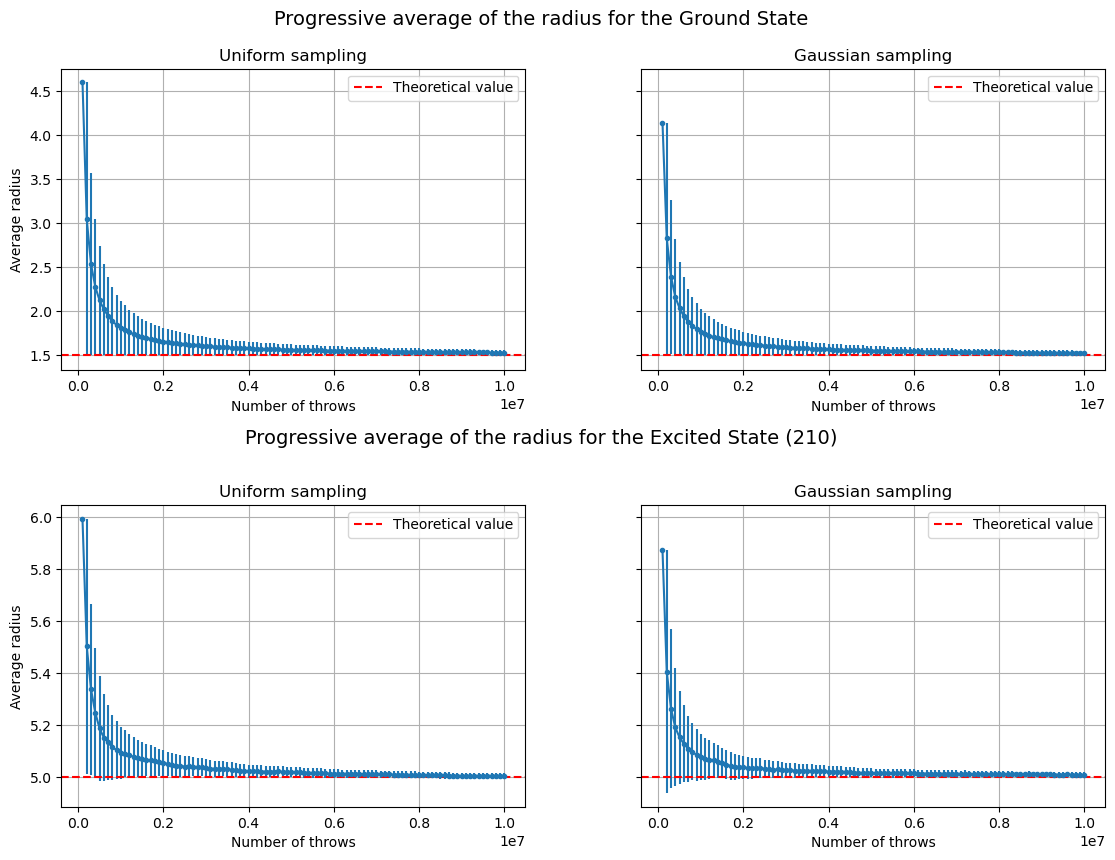

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 10^7 throws, 100 blocks -> 10^5 throws per block

data_far_from_origin = pd.read_csv("Results/Esercizio_05.1_results_far_from_origin.txt", sep=";")

# total number of throws and blocks
N_throws = 10000000
N_blocks = 100
throws_per_block = N_throws / N_blocks

x = np.arange(1, N_blocks + 1) * throws_per_block

# theoretical values
r_theory_fundamental = 1.5
r_theory_excited = 5.0   # 2p excited state

fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharey='row')

# first row
axs[0, 0].errorbar(
    x,
    data_far_from_origin["Progressive_r_uniform_fundamental"],
    yerr=data_far_from_origin["Progressive_r_uniform_fundamental_error"],
    fmt="-", marker="o", ms=3
)
axs[0, 0].set_title("Uniform sampling")
axs[0, 0].set_xlabel("Number of throws")
axs[0, 0].set_ylabel("Average radius")
axs[0, 0].axhline(r_theory_fundamental, color='r', linestyle='--', label="Theoretical value")
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].errorbar(
    x,
    data_far_from_origin["Progressive_r_gaussian_fundamental"],
    yerr=data_far_from_origin["Progressive_r_gaussian_fundamental_error"],
    fmt="-", marker="o", ms=3
)
axs[0, 1].set_title("Gaussian sampling")
axs[0, 1].set_xlabel("Number of throws")
axs[0, 1].axhline(r_theory_fundamental, color='r', linestyle='--', label="Theoretical value")
axs[0, 1].grid(True)
axs[0, 1].legend()

# second row
axs[1, 0].errorbar(
    x,
    data_far_from_origin["Progressive_r_uniform_excited"],
    yerr=data_far_from_origin["Progressive_r_uniform_excited_error"],
    fmt="-", marker="o", ms=3
)
axs[1, 0].set_title("Uniform sampling")
axs[1, 0].set_xlabel("Number of throws")
axs[1, 0].set_ylabel("Average radius")
axs[1, 0].axhline(r_theory_excited, color='r', linestyle='--', label="Theoretical value")
axs[1, 0].grid(True)
axs[1, 0].legend()

axs[1, 1].errorbar(
    x,
    data_far_from_origin["Progressive_r_gaussian_excited"],
    yerr=data_far_from_origin["Progressive_r_gaussian_excited_error"],
    fmt="-", marker="o", ms=3
)
axs[1, 1].set_title("Gaussian sampling")
axs[1, 1].set_xlabel("Number of throws")
axs[1, 1].axhline(r_theory_excited, color='r', linestyle='--', label="Theoretical value")
axs[1, 1].grid(True)
axs[1, 1].legend()

# spazio tra righe e margini
fig.subplots_adjust(top=0.90, bottom=0.08, left=0.10, right=0.97, hspace=0.45, wspace=0.25)

# titolo prima riga
fig.text(
    0.5, 0.955,
    "Progressive average of the radius for the Ground State",
    ha='center', va='center', fontsize=14
)

# titolo seconda riga
fig.text(
    0.5, 0.49,
    "Progressive average of the radius for the Excited State (210)",
    ha='center', va='center', fontsize=14
)

plt.show()

Starting very far from the origin, the Metropolis chain needs a much longer time to reach the region that is typical of the target distribution. The first samples are therefore not representative of equilibrium and the progressive averages are initially biased by the starting point. This is why, in a production run, one should discard an initial burn-in/equilibration part before measuring observables.

### Metropolis sampling of the system configurations far from the origin

The sampled configurations confirm the same point visually. The chain starts from a region that does not represent the equilibrium distribution and only gradually approaches the physically relevant part of configuration space.

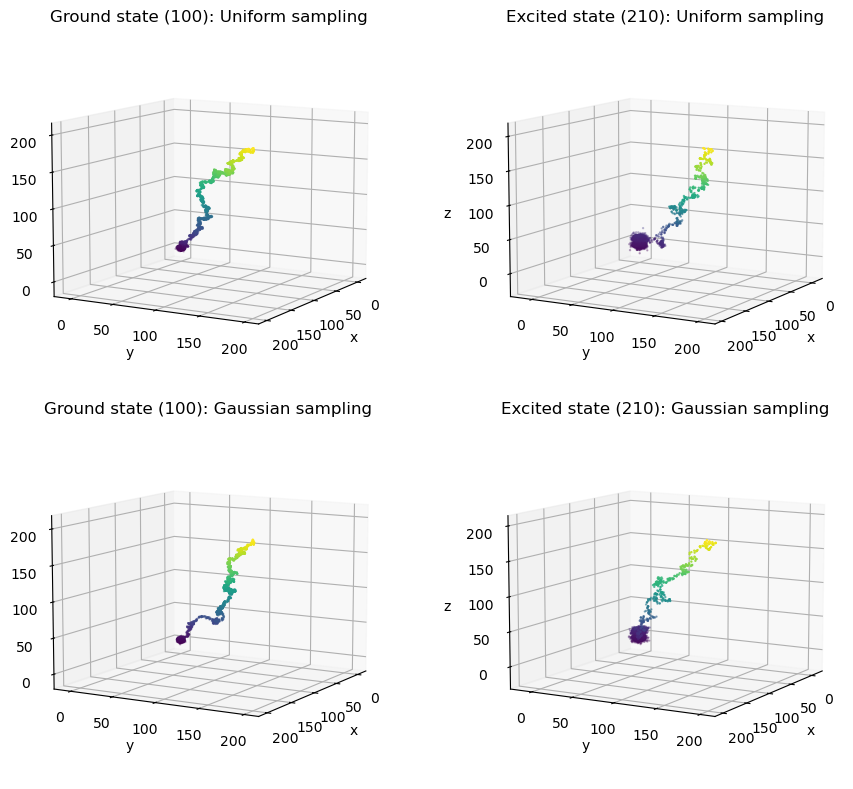

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

df1_far_from_origin = pd.read_csv("trajectories/trajectory_uniform_100_far_from_origin.dat", sep=r"\s+")
df2_far_from_origin = pd.read_csv("trajectories/trajectory_uniform_210_far_from_origin.dat", sep=r"\s+")
df3_far_from_origin = pd.read_csv("trajectories/trajectory_gaussian_100_far_from_origin.dat", sep=r"\s+")
df4_far_from_origin = pd.read_csv("trajectories/trajectory_gaussian_210_far_from_origin.dat", sep=r"\s+")

fig = plt.figure(figsize=(10, 8))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

ax1.scatter(df1_far_from_origin["x"], df1_far_from_origin["y"], df1_far_from_origin["z"], c=df1_far_from_origin["z"], marker='.', s=2)
ax1.set_title(r"Ground state (100): Uniform sampling")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.view_init(10, 30)

ax2.scatter(df2_far_from_origin["x"], df2_far_from_origin["y"], df2_far_from_origin["z"], c=df2_far_from_origin["z"], marker='.', s=2)
ax2.set_title(r"Excited state (210): Uniform sampling")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("z")
ax2.view_init(10, 30)

ax3.scatter(df3_far_from_origin["x"], df3_far_from_origin["y"], df3_far_from_origin["z"], c=df3_far_from_origin["z"], marker='.', s=2)
ax3.set_title(r"Ground state (100): Gaussian sampling")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")
ax3.view_init(10, 30)

ax4.scatter(df4_far_from_origin["x"], df4_far_from_origin["y"], df4_far_from_origin["z"], c=df4_far_from_origin["z"], marker='.', s=2)
ax4.set_title(r"Excited state (210): Gaussian sampling")
ax4.set_xlabel("x")
ax4.set_ylabel("y")
ax4.set_zlabel("z")
ax4.view_init(10, 30)

plt.tight_layout()
plt.show()

#### Comment

The trajectories show the initial transient from the remote starting point toward the region where the target probability density is significant. Even when the chain starts very far from the origin, the Metropolis dynamics is able to move toward the relevant region of configuration space and eventually sample the same target distribution.

This behaviour is consistent with the practical ergodicity of the Markov chain: the transition rule allows the chain to explore the relevant regions of the target distribution, rather than remaining confined near the initial condition. However, the first part of the trajectory is not representative of equilibrium and must not be included in a production estimate unless an appropriate equilibration phase has been discarded.

### How large should be the number of Monte Carlo Metropolis steps in each block?

The number of Metropolis steps in each block must be large compared with the autocorrelation time of the Markov chain. This is important because consecutive Metropolis configurations are correlated: if the blocks are too short, the block averages can still be correlated and the statistical uncertainty may be underestimated.

On the other hand, the blocks should not be so long that only a few blocks remain, because the uncertainty is estimated from the fluctuations among block averages. Therefore one needs a compromise: blocks should be long enough to reduce the effect of correlations, but the number of blocks should remain large enough to provide a meaningful estimate of the statistical error.

In this simulation, $10^5$ Metropolis steps per block and $100$ blocks are used. This choice is reasonable for the present calculation, since the final estimates are stable within the quoted uncertainties and are compatible with the theoretical values.